In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import random
from pathlib import Path
import sys
import json

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, HashingVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD

from catboost import CatBoostClassifier

In [3]:
project_root = Path().resolve().parent

# добавляем в sys.path
sys.path.append(str(project_root))

from core.graf import *
from core.func import *

d:\Python\Learning\NLP_Classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
SEED = 42
random.seed(SEED)

In [5]:
data_path = "../data/News_Category_Dataset_v3.json"

with open(data_path, 'r') as file:
    data = pd.DataFrame([json.loads(line) for line in file])

data.sample(5)

,link,headline,category,short_description,authors,date
6945,https://www.huffpost.com/entry/1-dead-17-hurt-...,"Officials: 1 Dead, 17 Hurt In North Carolina G...",U.S. NEWS,Durham Fire Chief Robert Zoldos said the blast...,,2019-04-11
205985,https://www.huffingtonpost.com/entry/childrens...,My Daughter the Fox and the Making of Children...,PARENTING,A parent's job is not only to serve as a story...,"Davis Schneiderman, Contributor\nAuthor. Acade...",2012-03-06
122547,https://www.huffingtonpost.com/entry/a-dog-day...,A Dog Day Afternoon,GOOD NEWS,With the constant stream of horrible (although...,"Ben Purdy, ContributorOccasional writer, full-...",2014-08-24
148363,https://www.huffingtonpost.com/entry/whither-y...,Whither Ye Olde Stomping Grounds?,TRAVEL,So I asked the sales person about the ingredie...,"Magda Abu-Fadil, Contributor\nDirector of Medi...",2013-11-11
166133,https://www.huffingtonpost.com/entry/mothers-d...,Mother's Day Gifts From The Best Mom-Focused P...,STYLE & BEAUTY,"This week on Hot on Pinterest, we found some g...",Michelle Persad,2013-05-07


In [6]:
preprocesed_data = data.copy()
preprocesed_data.drop_duplicates(inplace=True)
preprocesed_data["headline"] = preprocesed_data["headline"].str.replace("’", "'")
preprocesed_data["short_description"] = preprocesed_data["short_description"].str.replace("’", "'")

In [7]:
preprocesed_data

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22
...,...,...,...,...,...,...
209522,https://www.huffingtonpost.com/entry/rim-ceo-t...,RIM CEO Thorsten Heins' 'Significant' Plans Fo...,TECH,Verizon Wireless and AT&T are already promotin...,"Reuters, Reuters",2012-01-28
209523,https://www.huffingtonpost.com/entry/maria-sha...,Maria Sharapova Stunned By Victoria Azarenka I...,SPORTS,"Afterward, Azarenka, more effusive with the pr...",,2012-01-28
209524,https://www.huffingtonpost.com/entry/super-bow...,"Giants Over Patriots, Jets Over Colts Among M...",SPORTS,"Leading up to Super Bowl XLVI, the most talked...",,2012-01-28
209525,https://www.huffingtonpost.com/entry/aldon-smi...,Aldon Smith Arrested: 49ers Linebacker Busted ...,SPORTS,CORRECTION: An earlier version of this story i...,,2012-01-28


In [8]:
models = {
    'DummyClassifier': DummyClassifier(random_state=SEED, strategy='most_frequent'),
    'LogisticRegression': LogisticRegression(random_state=SEED, max_iter=1000,),
    'DecisionTree': DecisionTreeClassifier(random_state=SEED, max_depth=8),
    'RandomForest': RandomForestClassifier(random_state=SEED),
    'Cat': CatBoostClassifier(100, random_seed=SEED, early_stopping_rounds=5, task_type="GPU", verbose=False)
}

models

{'DummyClassifier': DummyClassifier(random_state=42, strategy='most_frequent'),
 'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
 'DecisionTree': DecisionTreeClassifier(max_depth=8, random_state=42),
 'RandomForest': RandomForestClassifier(random_state=42),
 'Cat': CatBoostClassifier(early_stopping_rounds=5, iterations=100, random_seed=42, task_type='GPU', verbose=False)}

In [ ]:
count_vectorizer_processor = Pipeline([
    ('vectorizer', ColumnTransformer(
        [
            ('headline_vectorizer', CountVectorizer(min_df=50, dtype=np.float32, stop_words='english', analyzer="word"), 'headline'),
            ('description_vectorizer', CountVectorizer(min_df=50, dtype=np.float32, stop_words='english', analyzer="word"), 'short_description'),
            ('authors_vectorizer', CountVectorizer(min_df=50, dtype=np.float32, stop_words='english', analyzer="word"), 'authors'),
        ],
        remainder='passthrough',
        verbose_feature_names_out=True
    ))
])

count_vectorizer_processor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('headline_vectorizer', ...), ('description_vectorizer', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of 

In [18]:
y = preprocesed_data['category']
X = preprocesed_data.drop(columns=['link', 'date', 'category'])
# X['headline'] = X['headline'].apply(tokenize_tiktoken)
# X['short_description'] = X['short_description'].apply(tokenize_tiktoken)
# X['authors'] = X['authors'].apply(tokenize_tiktoken)

Learning time of DummyClassifier: 19.42208456993103
Model DummyClassifier doesn't have attribute feature_importances_
Learning time of LogisticRegression: 118.84966564178467


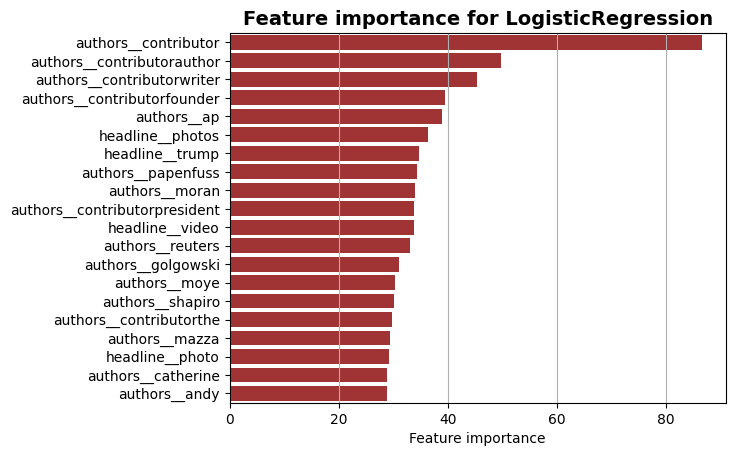

Learning time of DecisionTree: 25.305413722991943


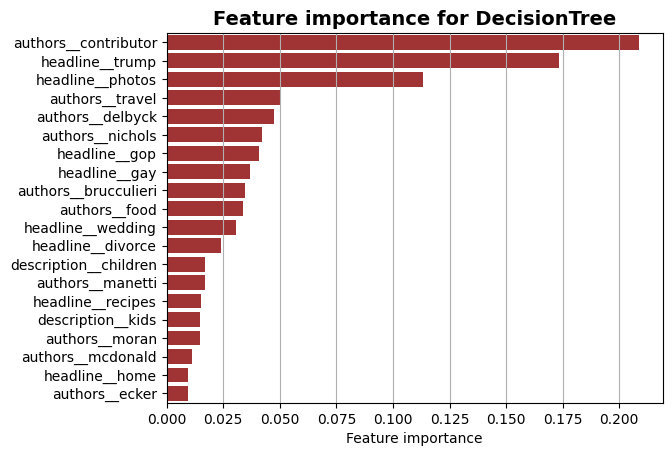

Learning time of RandomForest: 2683.7202653884888


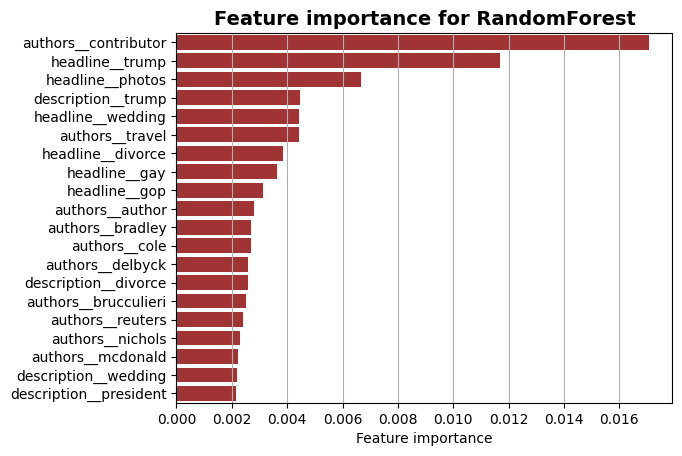

Learning time of Cat: 91.32489562034607


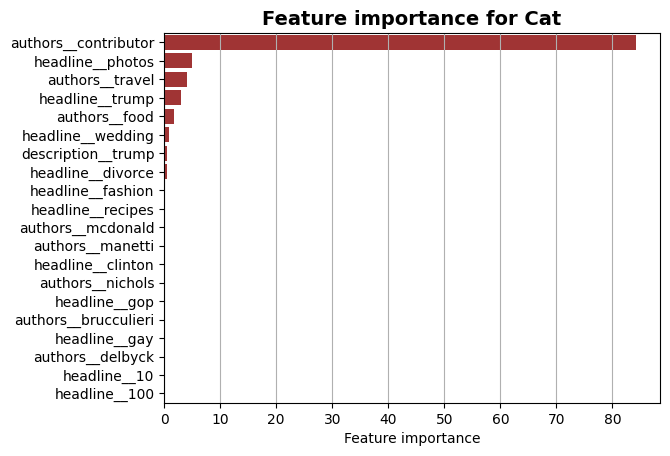

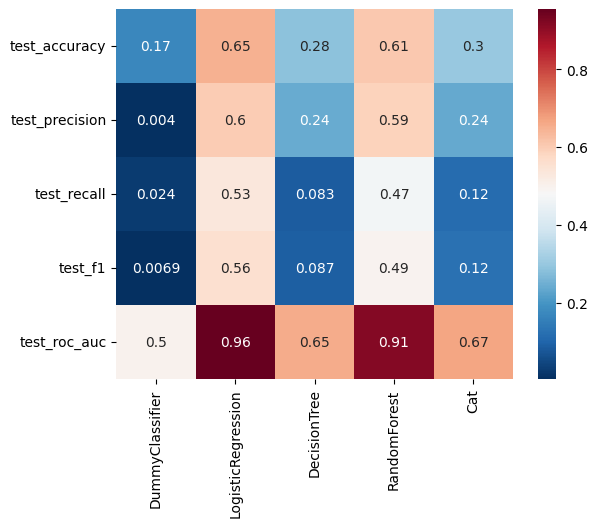

In [20]:
training_dict_of_models_cv(models, X, y, preprocessor=count_vectorizer_processor, cv=5)

In [ ]:
X['headline'] = X['headline'].apply(filter_tokens).apply(generate_ngrams)
X['short_description'] = X['short_description'].apply(filter_tokens).apply(generate_ngrams)
X['authors'] = X['authors'].apply(filter_tokens).apply(generate_ngrams)

Learning time of DummyClassifier: 11.769372701644897
Model DummyClassifier doesn't have attribute feature_importances_
Learning time of LogisticRegression: 150.2116343975067


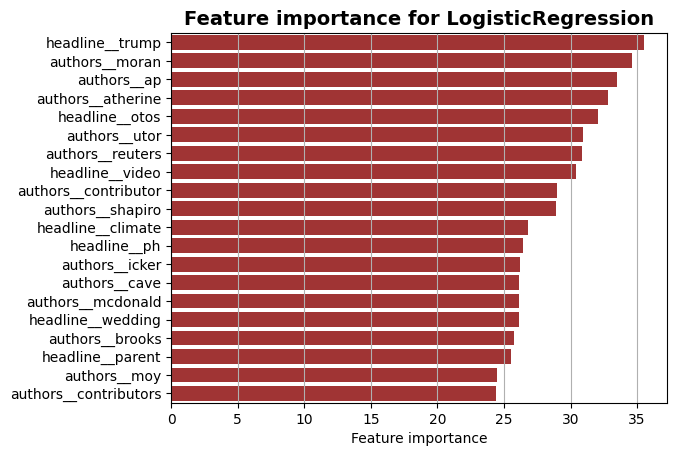

Learning time of DecisionTree: 18.75478768348694


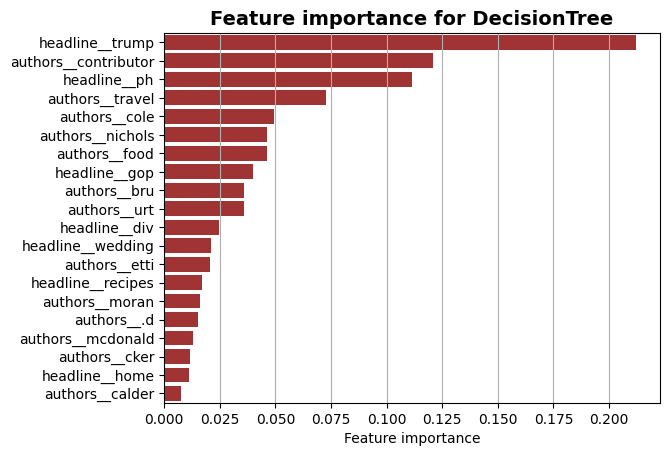

Learning time of RandomForest: 2921.962209224701


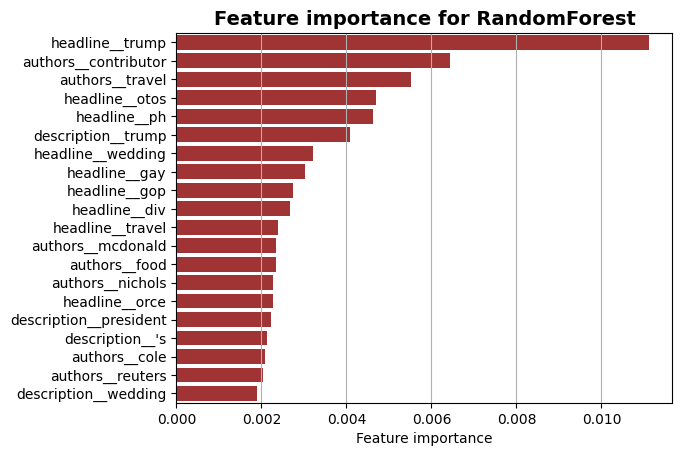

Learning time of Cat: 112.00060606002808


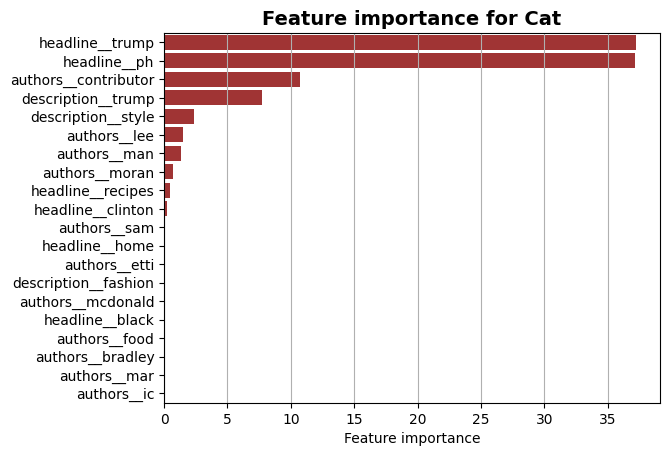

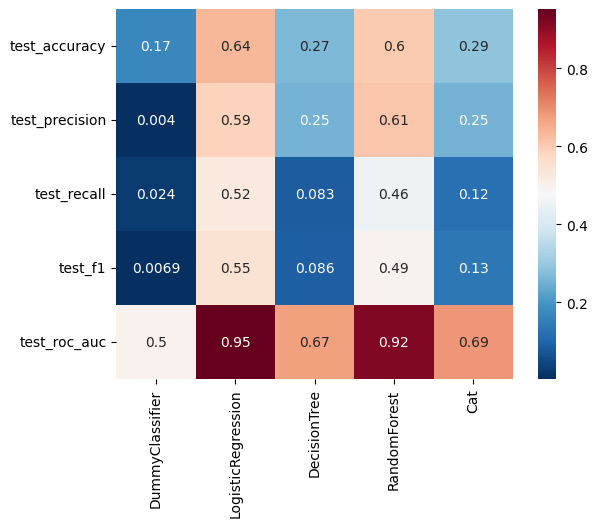

In [16]:
training_dict_of_models_cv(models, X, y, preprocessor=count_vectorizer_processor, cv=5)

In [ ]:
# seq_vectorizer_processor = Pipeline([
#     ('vectorizer', ColumnTransformer(
#         [
#         ('headline_vectorizer', HashingVectorizer(stop_words='english')),
#         ('description_vectorizer',HashingVectorizer()),
#         ('authors_vectorizer', HashingVectorizer())
#         ],
#         remainder='passthrough',
#         verbose_feature_names_out=True
#     )),
#     ('svd', TruncatedSVD(n_components=200)),
# ])


In [ ]:
# training_dict_of_models_cv(models, X, y, preprocessor=seq_vectorizer_processor, cv=5)

In [ ]:
tfidf_vectorizer_processor = Pipeline([
    ('vectorizer', ColumnTransformer(
        [
            ('headline_vectorizer', TfidfVectorizer(lowercase=True, strip_accents='unicode', analyzer='word', stop_words='english'), 'headline'),
            ('description_vectorizer', TfidfVectorizer(lowercase=True, strip_accents='unicode', analyzer='word', stop_words='english'), 'short_description'),
            ('authors_vectorizer', TfidfVectorizer(lowercase=True, strip_accents='unicode', analyzer='word', stop_words='english'), 'authors'),
        ],
        remainder='passthrough',
        verbose_feature_names_out=True
    )),

    ('svd', TruncatedSVD(n_components=200)),
])

tfidf_vectorizer_processor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('svd', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('headline_vectorizer', ...), ('description_vectorizer', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If 

Learning time of DummyClassifier: 87.45252633094788
Model DummyClassifier doesn't have attribute feature_importances_
Learning time of LogisticRegression: 172.76404094696045


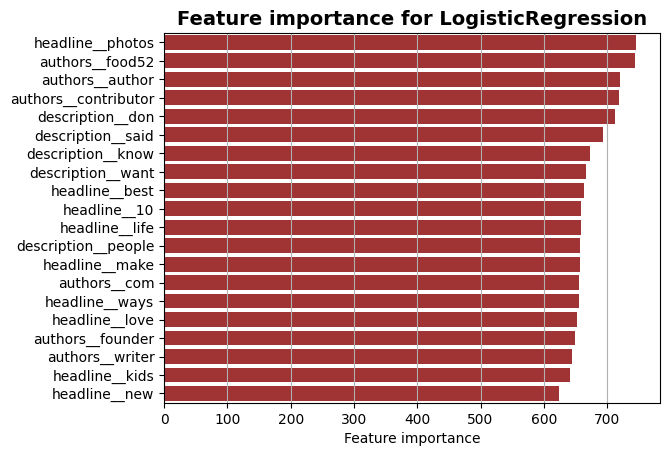

Learning time of DecisionTree: 253.95949006080627


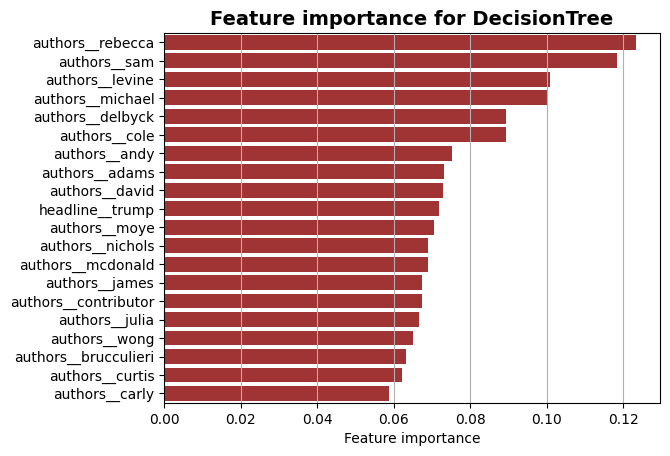

Learning time of RandomForest: 2237.4338533878326


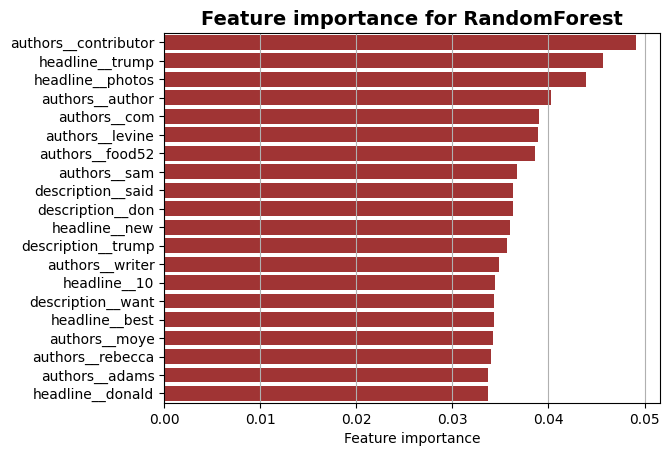

Learning time of Cat: 106.41580986976624


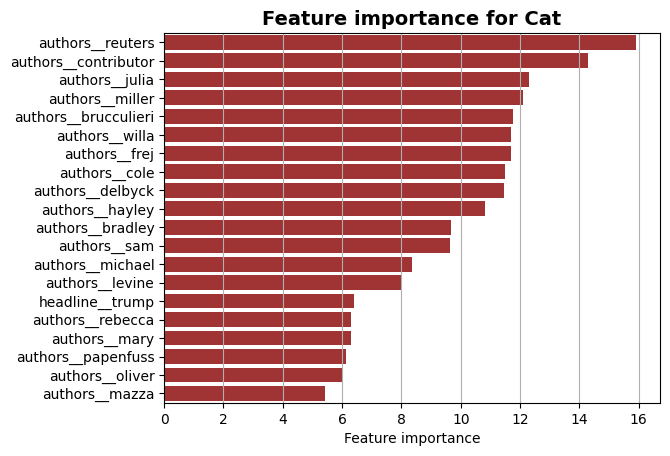

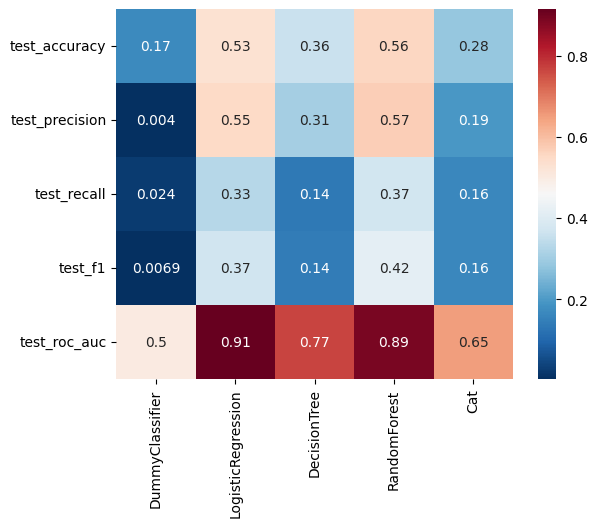

In [22]:
training_dict_of_models_cv(models, X, y, preprocessor=tfidf_vectorizer_processor, cv=5)